In [161]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix





In [162]:
# -------------------------------------------------------------------------
# STEP 1: LOAD THE DATA

df = pd.read_csv("ai4i2020.csv")
print("--- Dataset Shape ---")
print(df.shape)

--- Dataset Shape ---
(10000, 14)


In [163]:
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [164]:
# -------------------------------------------------------------------------
# STEP 2: FEATURE ENGINEERING 
df['Temp_Difference'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power_Output'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']

print("\n--- Features Created Successfully ---")
print(df[['Temp_Difference', 'Power_Output']].head())


--- Features Created Successfully ---
   Temp_Difference  Power_Output
0             10.5       66382.8
1             10.5       65190.4
2             10.4       74001.2
3             10.4       56603.5
4             10.5       56320.0


In [165]:
# from ydata_profiling import ProfileReport
# prof = ProfileReport(df)
# prof.to_file(output_file='data_report_pred_maint.html')

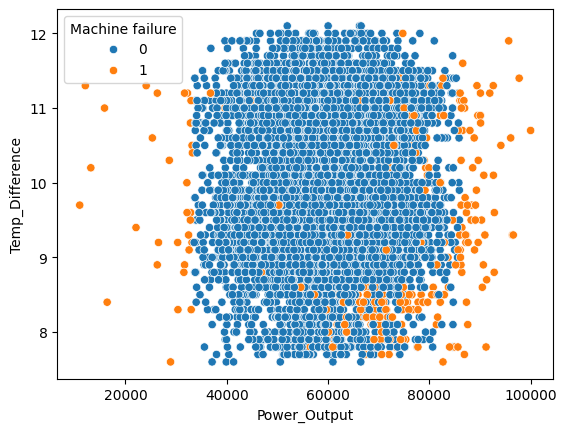

In [166]:
%matplotlib inline
sns.scatterplot(y=df['Temp_Difference'], x=df['Power_Output'], hue=df['Machine failure'])
plt.show()

In [167]:
leakage_columns = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
X = df.drop(columns=['Machine failure', 'UDI', 'Product ID']+ leakage_columns)

# 2. Convert the categorical 'Type' column into numerical format
X = pd.get_dummies(X, columns=['Type'], drop_first=True)

# 3 target
y = df['Machine failure']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17, stratify=y)

In [168]:
# -------------------------------------------------------------------------
# STEP 4: MODEL TRAINING
model = RandomForestClassifier(random_state=17, class_weight='balanced')
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [169]:
# STEP 5: EVALUATION
# -------------------------------------------------------------------------
y_pred = model.predict(X_test)

print("\n - Confusion Matrix ")
print(confusion_matrix(y_test, y_pred))

#the accuracy as a percentage
acc = accuracy_score(y_test, y_pred)
print(f"\n- Accuracy Score: {acc * 100:.2f}%")

print("\n - Classification Report -")
print(classification_report(y_test, y_pred))


 - Confusion Matrix 
[[1932    0]
 [  21   47]]

- Accuracy Score: 98.95%

 - Classification Report -
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       1.00      0.69      0.82        68

    accuracy                           0.99      2000
   macro avg       0.99      0.85      0.91      2000
weighted avg       0.99      0.99      0.99      2000



In [170]:
my_custom_machine = {
    'Air temperature [K]': [304.0],      
    'Process temperature [K]': [313.0],  
    'Rotational speed [rpm]': [1180],    # Very low speed...
    'Torque [Nm]': [76.0],               # ...combined with incredibly high torque
    'Tool wear [min]': [260],            
    'Temp_Difference': [9.0],
    'Power_Output': [89680],             # (1180 * 76) Extreme power load
    'Type_L': [1],                       
    'Type_M': [0]
}
new_data_df = pd.DataFrame(my_custom_machine)
new_data_df = new_data_df.reindex(columns=X_train.columns, fill_value=0)
prediction = model.predict(new_data_df)
print("--- Prediction Results ---")
if prediction[0] == 1:
    print("🚨 ALERT: The model predicts this machine will FAIL.")
else:
    print("✅ All good: The model predicts this machine is FINE.")

--- Prediction Results ---
🚨 ALERT: The model predicts this machine will FAIL.


In [171]:
import joblib

# This saves your trained Random Forest model as a file
joblib.dump(model, 'predictive_maintenance_model.joblib')
print("Model saved successfully!")

Model saved successfully!
